In [43]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import warnings
from scipy import stats
from scipy.stats.stats import pearsonr
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_selection import SelectKBest, f_regression

In [44]:
%matplotlib inline
warnings.filterwarnings("ignore")
pd.set_option('display.expand_frame_repr', False)

IN THIS EXAMPLE THE **INPUT COLUMN AND TARGET COLUMNS BOTH ARE CONTINUOUS VARIABLE** AND SCORING CRITERIA IS **f_regression**

In [45]:
df = pd.read_csv('data.csv')
df.shape

(155, 5)

In [46]:
df.head()

,X1,X2,X3,X4,Y
0,2.53,285,62.750,1394.46,1187.0
1,2.85,280,37.875,1366.42,1149.1
2,2.27,266,44.000,1498.58,1268.3
3,2.43,280,59.250,1420.60,1124.9
4,2.46,281,23.938,1454.60,1194.5


In [47]:
# Split df into x and Y
target_col = "Y"
X = df.loc[:, df.columns != target_col]
y = df.loc[:, target_col]

In [48]:
# Split the data into train and test with 70% data being used for training
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.30,
                                                    random_state=42)

In [49]:
X_train.head()

,X1,X2,X3,X4
141,2.12,236,15.778,2471.65
66,4.55,328,13.375,1549.38
119,0.74,335,15.610,1848.36
27,3.79,436,8.000,841.15
79,0.70,620,86.625,872.81


In [50]:
X_new = SelectKBest(f_regression, k=2).fit_transform(X_train, y_train)
X_new[0:5]

array([[ 236.  , 2471.65],
       [ 328.  , 1549.38],
       [ 335.  , 1848.36],
       [ 436.  ,  841.15],
       [ 620.  ,  872.81]])

#Relationship of Features with Response Variables

In [51]:
def plot_joint_plot(df, feature, target):
    j = sns.jointplot(data=df, x=feature, y=target, kind='reg')
    j.annotate(stats.pearsonr)
    return plt.show()

In [52]:
train_df = pd.concat([X_train, pd.DataFrame(y_train, columns=[target_col])], axis=1)

AttributeError: ignored

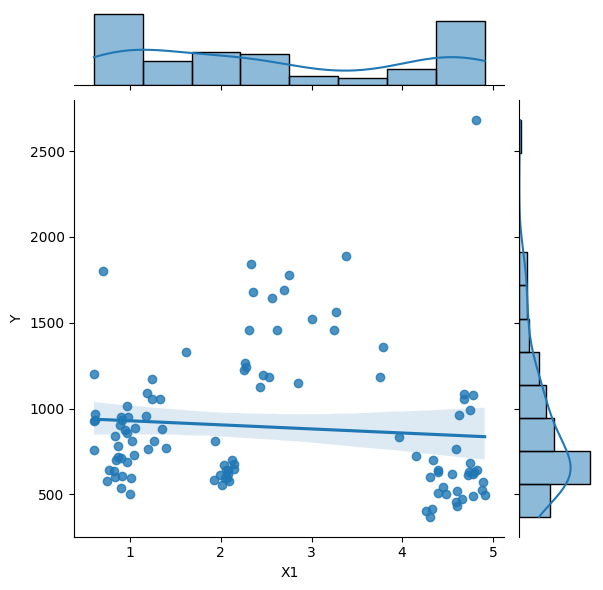

In [56]:
plot_joint_plot(train_df,"X1",target_col)

AttributeError: ignored

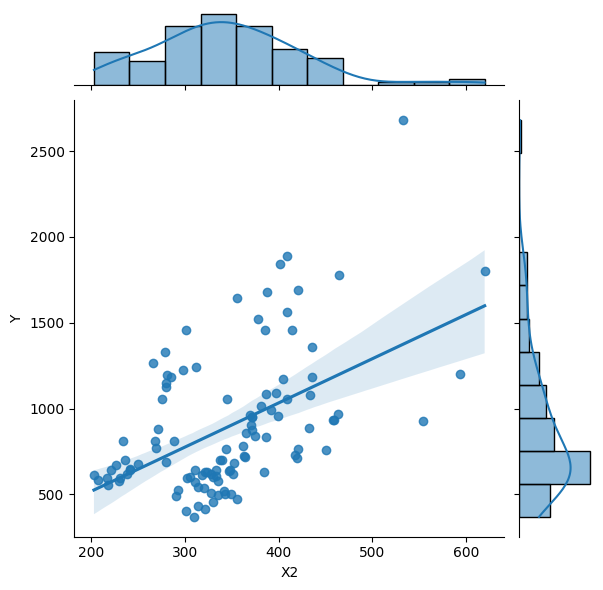

In [57]:
plot_joint_plot(train_df,"X2",target_col)

AttributeError: ignored

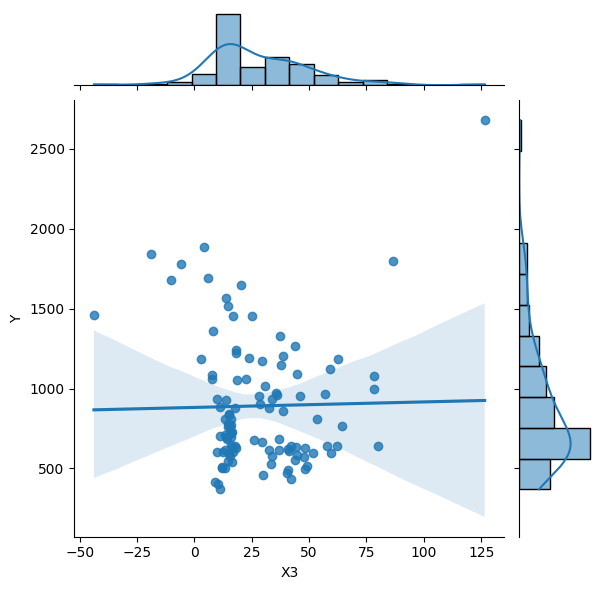

In [58]:
plot_joint_plot(train_df,"X3",target_col)

AttributeError: ignored

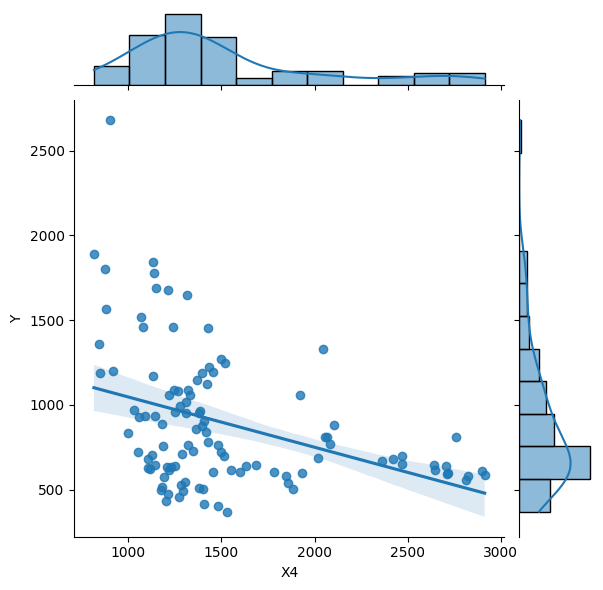

In [59]:
plot_joint_plot(train_df,"X4",target_col)

#Correlation Analysis using Pearson Analysis

In [60]:
pearsonr(X_train["X4"], y_train)

PearsonRResult(statistic=-0.3925245911796265, pvalue=2.649328996655486e-05)

In [61]:
out_list = []
for column in X_train.columns:
    corr_tuple = pearsonr(X_train[column], y_train)
    out_list.append([column, corr_tuple[0], corr_tuple[1]])

In [62]:
corr_df = pd.DataFrame(out_list, columns=["Features", "Correlation", "P-Value"])

In [63]:
corr_df.head()

,Features,Correlation,P-Value
0,X1,-0.091239,3.476728e-01
1,X2,0.506263,2.274708e-08
2,X3,0.019741,8.393037e-01
3,X4,-0.392525,2.649329e-05


In [64]:
corr_df.sort_values(by=['P-Value'], inplace=True)
corr_df.head()

,Features,Correlation,P-Value
1,X2,0.506263,2.274708e-08
3,X4,-0.392525,2.649329e-05
0,X1,-0.091239,3.476728e-01
2,X3,0.019741,8.393037e-01
